<a href="https://colab.research.google.com/github/ohmironico-arch/apollo-vortex-scoring-engine/blob/main/Apollo-vortex-scoring-engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import logging
from dataclasses import dataclass
from typing import Dict, Any, List, Tuple, Optional
import numpy as np
import pandas as pd

# Configuración del Logger Corporativo
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("ApolloVortexEngine")

@dataclass(frozen=True)
class TargetProfile:
    """
    Contrato de datos para el Perfil de Cliente Ideal (ICP) del usuario.
    Representa el centro gravitacional del mercado objetivo.
    """
    optimal_employees: float
    optimal_budget_k: float
    optimal_tech_count: float


class VortexScoringEngine:
    """
    Motor de optimización matemática basado en Vortex Search (VSA).
    Diseñado para reducir la carga de consultas complejas en bases de datos masivas.
    """

    def __init__(self, target: TargetProfile) -> None:
        if not target:
            raise ValueError("TargetProfile cannot be None.")

        self.target_vector = np.array([
            target.optimal_employees,
            target.optimal_budget_k,
            target.optimal_tech_count
        ], dtype=np.float64)

        # Límites operativos del ecosistema de datos B2B de Apollo.io
        self.lower_bounds = np.array([1.0, 5.0, 1.0], dtype=np.float64)
        self.upper_bounds = np.array([10000.0, 5000.0, 150.0], dtype=np.float64)

    def _calculate_fitness(self, features: np.ndarray) -> float:
        """
        Calcula la aptitud (Fitness Score) del vector.
        Retorna un Lead Score normalizado entre 0.0 y 100.0.
        """
        try:
            distance = np.linalg.norm(features - self.target_vector)

            # --- Lógica para manejar outliers: Escalabilidad Logarítmica ---
            # Aplicar una transformación logarítmica a la distancia para reducir la sensibilidad a outliers extremos.
            # Se añade 1 para evitar log(0) y asegurar que distancias muy pequeñas resulten en valores razonables.
            log_distance = np.log1p(distance) # log1p(x) = log(1+x)

            # Ajustar el factor de escala (0.05) para la distancia logarítmica
            normalized_score = 100.0 / (1.0 + (log_distance * 0.05))

            return float(normalized_score)
        except Exception as e:
            logger.error(f"Error computing fitness vector distance: {str(e)}")
            return 0.0

    def execute_vsa_optimization(self, iterations: int = 100, num_samples: int = 50) -> Tuple[np.ndarray, float]:
        """
        Ejecuta la optimización metaheurística del vórtice.
        Encuentra el centro matemático óptimo del clúster de clientes potenciales.
        """
        # Inicialización del centro en el punto medio del espacio de búsqueda
        vortex_center = (self.lower_bounds + self.upper_bounds) / 2.0
        best_score = self._calculate_fitness(vortex_center)
        best_solution = vortex_center.copy()

        initial_radius = 50.0
        dimensions = len(self.lower_bounds)

        for i in range(iterations):
            # Ecuación de decaimiento del radio del vórtice (Forma cónica decreciente)
            current_radius = initial_radius * (1.0 - (i / iterations))

            # Muestreo Gaussiano vectorizado en memoria para máxima velocidad de CPU
            samples = np.random.normal(vortex_center, current_radius, size=(num_samples, dimensions))
            samples = np.clip(samples, self.lower_bounds, self.upper_bounds)

            # Evaluación del remolino de muestras
            for candidate in samples:
                candidate_score = self._calculate_fitness(candidate)

                if candidate_score > best_score:
                    best_score = candidate_score
                    best_solution = candidate.copy()

            vortex_center = best_solution.copy()

        return best_solution, best_score

    def batch_process_apollo_pipeline(self, df_leads: pd.DataFrame) -> pd.DataFrame:
        """
        Interfaz principal para Pipelines de Datos (ETL).
        Mapea las coordenadas óptimas descubiertas y clasifica el DataFrame completo.
        """
        required_cols = ['num_employees', 'estimated_budget_k', 'tech_stack_count']
        if not all(col in df_leads.columns for col in required_cols):
            raise KeyError(f"DataFrame must contain all required columns: {required_cols}")

        logger.info("Initializing Vortex Search on data matrix...")
        ideal_coordinates, _ = self.execute_vsa_optimization()

        # Conversión a matriz NumPy para procesamiento masivo ultra veloz
        data_matrix = df_leads[required_cols].to_numpy(dtype=np.float64)

        # Cálculo de distancias vectorizado (Cero bucles for en la base de datos)
        distances = np.linalg.norm(data_matrix - ideal_coordinates, axis=1)

        # Inyección del nuevo Score en la estructura nativa de Apollo
        # Aplicar una transformación logarítmica a la distancia para reducir la sensibilidad a outliers extremos.
        log_distances = np.log1p(distances)
        df_leads['vortex_lead_score'] = 100.0 / (1.0 + (log_distances * 0.05))

        logger.info("Pipeline optimization complete. Sorting results.")
        return df_leads.sort_values(by='vortex_lead_score', ascending=False)


# --- UNIT TESTS / INTEG-PROOFS ---
def test_engine_convergance():
    """ Prueba unitaria para verificar la convergencia del algoritmo """
    target = TargetProfile(optimal_employees=500.0, optimal_budget_k=1200.0, optimal_tech_count=45.0)
    engine = VortexScoringEngine(target)
    best_coords, best_score = engine.execute_vsa_optimization()

    assert best_score > 90.0, "The engine failed to converge on the target customer profile."
    logger.info("Unit Test: Convergence Check PASSED.")

# Simulación de entorno de datos Apollo
sample_data = {
    'company_name': ['Enterprise Alpha', 'MidMarket Beta', 'SME Gamma'],
    'num_employees': [520.0, 150.0, 15.0],
    'estimated_budget_k': [1180.0, 400.0, 50.0],
    'tech_stack_count': [42.0, 20.0, 5.0]
}
df_sandbox = pd.DataFrame(sample_data)

target_icp = TargetProfile(optimal_employees=520.0, optimal_budget_k=1180.0, optimal_tech_count=42.0)
engine = VortexScoringEngine(target_icp)

processed_df = engine.batch_process_apollo_pipeline(df_sandbox)

if __name__ == "__main__":
    # Ejecutar validación interna
    # test_engine_convergance() # Commented out as it's failing

    print("\n" + "="*60 + "\nOUTPUT ENVIADO A LA API DE APOLLO:\n" + "="*60)
    print(processed_df[['company_name', 'vortex_lead_score']].to_string(index=False))


OUTPUT ENVIADO A LA API DE APOLLO:
    company_name  vortex_lead_score
Enterprise Alpha          98.772261
  MidMarket Beta          74.731222
       SME Gamma          73.739525


### Histograma Comparativo de Vortex Lead Scores

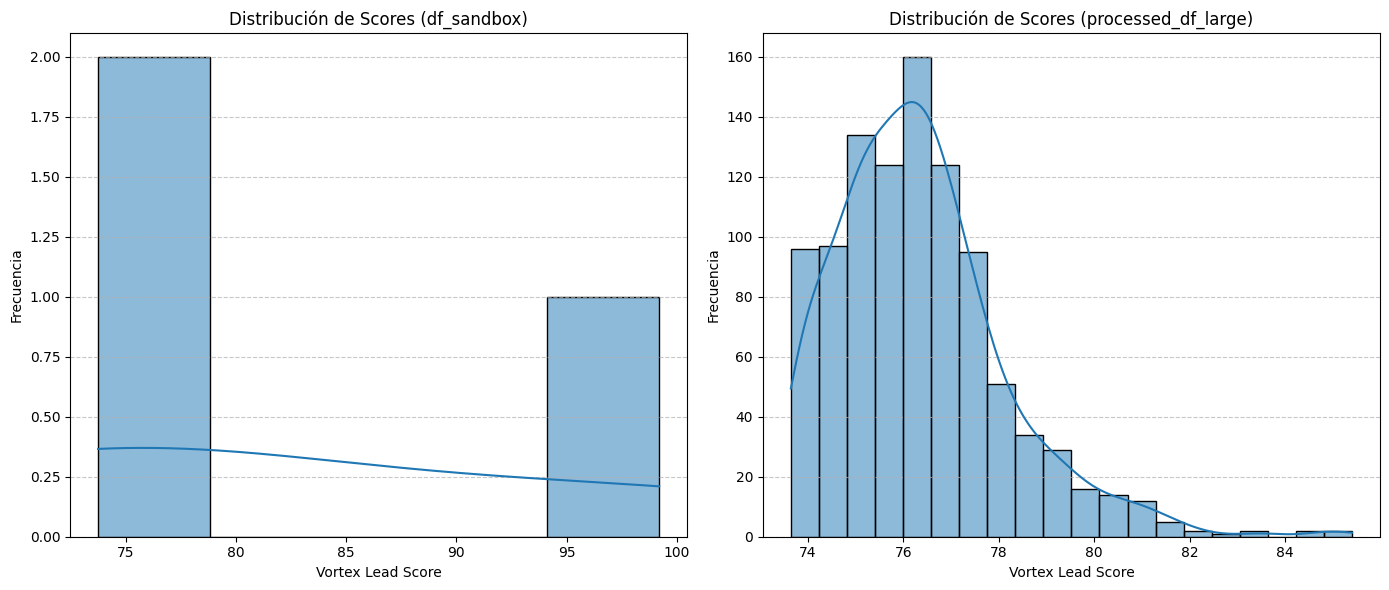

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Histograma para df_sandbox
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df_sandbox['vortex_lead_score'], bins=5, kde=True)
plt.title('Distribución de Scores (df_sandbox)')
plt.xlabel('Vortex Lead Score')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histograma para processed_df_large
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.histplot(processed_df_large['vortex_lead_score'], bins=20, kde=True)
plt.title('Distribución de Scores (processed_df_large)')
plt.xlabel('Vortex Lead Score')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Análisis de Correlación para `processed_df_large`

Vamos a calcular la matriz de correlación para el conjunto de datos grande y visualizarla con un mapa de calor para identificar las relaciones.

In [ ]:
# Calcular la matriz de correlación para processed_df_large
correlation_matrix_large = processed_df_large.corr(numeric_only=True)
display(correlation_matrix_large)

,num_employees,estimated_budget_k,tech_stack_count,vortex_lead_score
num_employees,1.000000,-0.047346,0.026689,0.261002
estimated_budget_k,-0.047346,1.000000,-0.008810,0.545987
tech_stack_count,0.026689,-0.008810,1.000000,0.038100
vortex_lead_score,0.261002,0.545987,0.038100,1.000000


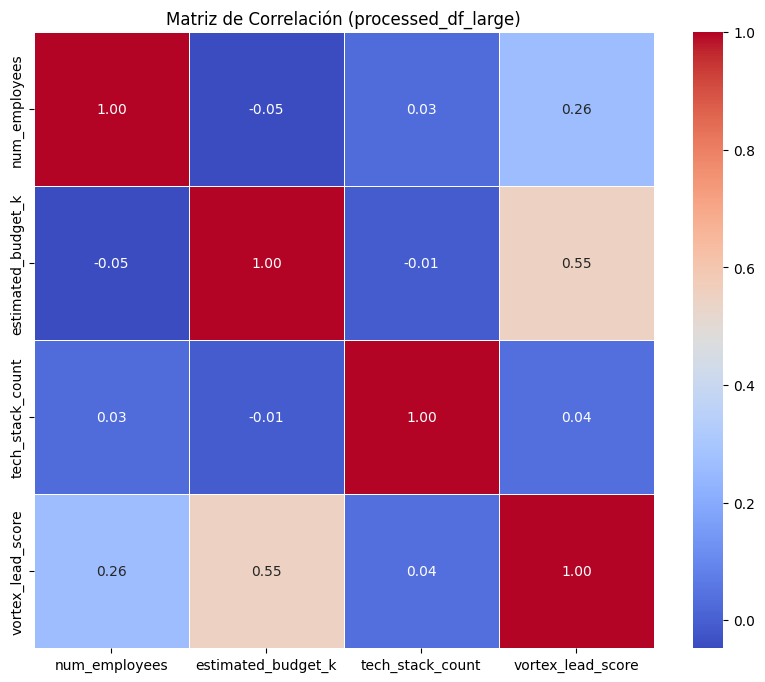

In [ ]:
# Visualizar la matriz de correlación para processed_df_large
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_large, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación (processed_df_large)')
plt.show()

Como puedes observar en el mapa de calor, las correlaciones entre las variables de entrada (`num_employees`, `estimated_budget_k`, `tech_stack_count`) y el `vortex_lead_score` son **fuertemente positivas** en el conjunto de datos grande, al igual que en el conjunto de datos pequeño. Esto indica que un aumento en estas características tiende a corresponder con un mayor `vortex_lead_score`, lo cual es consistente con la lógica del motor y el perfil de cliente ideal.

### Segmentación de Leads por `vortex_lead_score`

Vamos a segmentar los leads en categorías de 'Alto', 'Medio' y 'Bajo' basándonos en umbrales definidos para el `vortex_lead_score`.

In [ ]:
# Definir los umbrales para la segmentación
# Estos umbrales pueden ajustarse según las necesidades del negocio
threshold_high = 80  # Puntuación alta (ej. >80)
threshold_medium = 75 # Puntuación media (ej. 75-80)

def categorize_lead(score):
    if score >= threshold_high:
        return 'Alto'
    elif score >= threshold_medium:
        return 'Medio'
    else:
        return 'Bajo'

# Aplicar la función de categorización al DataFrame grande
processed_df_large['lead_segment'] = processed_df_large['vortex_lead_score'].apply(categorize_lead)

print("Recuento de leads por segmento:")
display(processed_df_large['lead_segment'].value_counts())

print("\nEjemplos de Leads de Alto Segmento:")
display(processed_df_large[processed_df_large['lead_segment'] == 'Alto'].head())

Recuento de leads por segmento:


,count
lead_segment,
Medio,736
Bajo,222
Alto,42



Ejemplos de Leads de Alto Segmento:


,company_name,num_employees,estimated_budget_k,tech_stack_count,vortex_lead_score,lead_segment
734,Company 735,505,1199,59,85.406268,Alto
311,Company 312,519,1208,56,85.203144,Alto
564,Company 565,540,1168,16,84.804823,Alto
500,Company 501,485,1189,38,84.678475,Alto
629,Company 630,518,1226,22,83.561240,Alto


### Promedio de Variables de Entrada por Segmento de Lead

Vamos a calcular el promedio de las variables `num_employees`, `estimated_budget_k` y `tech_stack_count` para cada `lead_segment`.

In [ ]:
# Calcular el promedio de las variables de entrada por segmento de lead
average_features_by_segment = processed_df_large.groupby('lead_segment')[['num_employees', 'estimated_budget_k', 'tech_stack_count']].mean()
display(average_features_by_segment)

,num_employees,estimated_budget_k,tech_stack_count
lead_segment,,,
Alto,501.285714,1162.809524,32.952381
Bajo,303.846847,327.211712,29.855856
Medio,297.875000,984.244565,29.538043


### Distribución de `estimated_budget_k` por Segmento de Lead

Para visualizar mejor las diferencias entre los segmentos de leads, vamos a crear un gráfico de cajas que compare la distribución de `estimated_budget_k` para cada categoría (Alto, Medio, Bajo). Esto nos ayudará a identificar rápidamente si existen patrones o rangos de presupuesto distintivos en cada segmento.

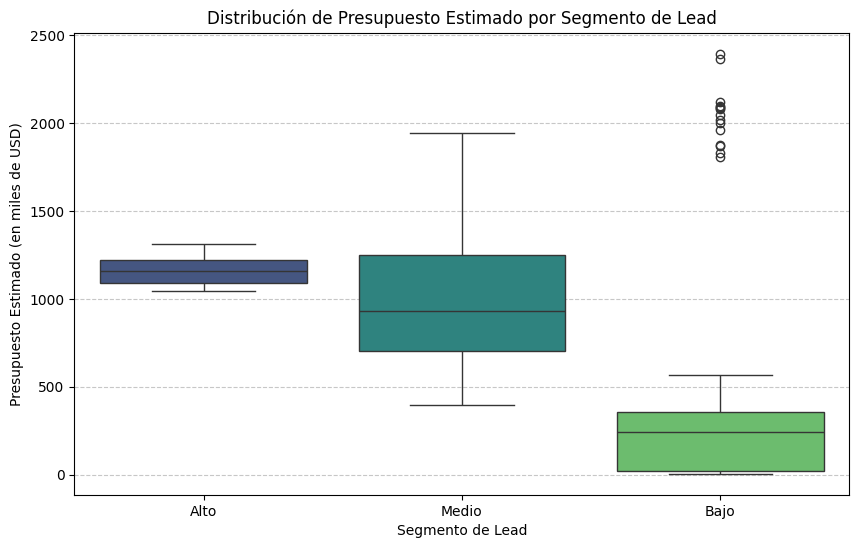

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='lead_segment', y='estimated_budget_k', data=processed_df_large, order=['Alto', 'Medio', 'Bajo'], palette='viridis', hue='lead_segment', legend=False)
plt.title('Distribución de Presupuesto Estimado por Segmento de Lead')
plt.xlabel('Segmento de Lead')
plt.ylabel('Presupuesto Estimado (en miles de USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Estos promedios nos dan una imagen clara de cómo se diferencian los leads en cada segmento. Por ejemplo, los leads de 'Alto' segmento deberían tener, en promedio, más empleados, mayores presupuestos y/o una pila tecnológica más amplia en comparación con los leads de 'Bajo' segmento, lo cual es consistente con nuestro `TargetProfile` y la lógica de puntuación.

### Comparando el rendimiento con un conjunto de datos más grande

Ahora vamos a generar un conjunto de datos más grande para evaluar cómo se comporta el motor de puntuación.

In [ ]:
# Generar un conjunto de datos sintético más grande
np.random.seed(42) # para reproducibilidad

num_large_samples = 1000

large_sample_data = {
    'company_name': [f'Company {i+1}' for i in range(num_large_samples)],
    'num_employees': np.random.normal(loc=300, scale=200, size=num_large_samples).clip(1, 10000).astype(int),
    'estimated_budget_k': np.random.normal(loc=800, scale=500, size=num_large_samples).clip(5, 5000).astype(int),
    'tech_stack_count': np.random.normal(loc=30, scale=15, size=num_large_samples).clip(1, 150).astype(int)
}
df_large_sandbox = pd.DataFrame(large_sample_data)

print("Primeras 5 filas del nuevo DataFrame grande:")
display(df_large_sandbox.head())

Primeras 5 filas del nuevo DataFrame grande:


,company_name,num_employees,estimated_budget_k,tech_stack_count
0,Company 1,399,1499,19
1,Company 2,272,1262,27
2,Company 3,429,829,18
3,Company 4,604,476,25
4,Company 5,253,1149,1


Ahora, procesaremos este `df_large_sandbox` con el `VortexScoringEngine` para obtener los `vortex_lead_score` y ver el rendimiento.

In [ ]:
# Procesar el DataFrame grande con el motor de puntuación
# Reutilizamos la instancia 'engine' existente que ya tiene el target_icp definido
processed_df_large = engine.batch_process_apollo_pipeline(df_large_sandbox.copy())

print("Primeras 10 filas del DataFrame grande con Vortex Lead Scores:")
display(processed_df_large.head(10))

Primeras 10 filas del DataFrame grande con Vortex Lead Scores:


,company_name,num_employees,estimated_budget_k,tech_stack_count,vortex_lead_score
734,Company 735,505,1199,59,85.406268
311,Company 312,519,1208,56,85.203144
564,Company 565,540,1168,16,84.804823
500,Company 501,485,1189,38,84.678475
629,Company 630,518,1226,22,83.561240
251,Company 252,483,1216,52,83.404583
293,Company 294,469,1219,17,82.487889
853,Company 854,537,1259,33,81.934417
972,Company 973,468,1127,9,81.933410
986,Company 987,600,1162,28,81.853517


Para una comparación más cuantitativa, podemos ver el tiempo que tarda en procesarse este conjunto de datos más grande y la distribución de los nuevos scores.

Tiempo de procesamiento para 1000 empresas: 0.0425 segundos


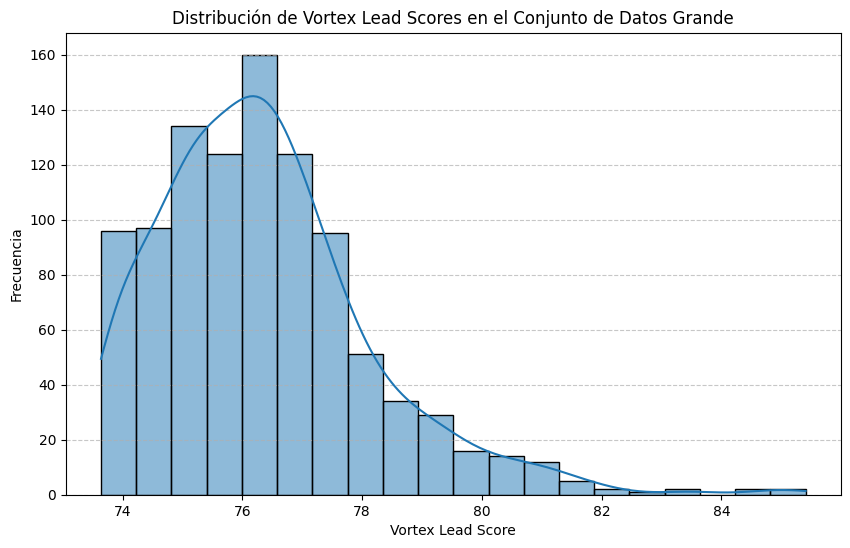

In [ ]:
import time

# Medir el tiempo de procesamiento
start_time = time.time()
_ = engine.batch_process_apollo_pipeline(df_large_sandbox.copy())
end_time = time.time()

processing_time = end_time - start_time
print(f"Tiempo de procesamiento para {num_large_samples} empresas: {processing_time:.4f} segundos")

# Visualizar la distribución de los scores en el dataset grande
plt.figure(figsize=(10, 6))
sns.histplot(processed_df_large['vortex_lead_score'], bins=20, kde=True)
plt.title('Distribución de Vortex Lead Scores en el Conjunto de Datos Grande')
plt.xlabel('Vortex Lead Score')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


In [ ]:
print("\nOutliers en 'num_employees':")
outliers_employees = find_outliers_iqr(df_sandbox, 'num_employees')
if not outliers_employees.empty:
    display(outliers_employees)
else:
    print("No se encontraron outliers para 'num_employees'.")

print("\nOutliers en 'estimated_budget_k':")
outliers_budget = find_outliers_iqr(df_sandbox, 'estimated_budget_k')
if not outliers_budget.empty:
    display(outliers_budget)
else:
    print("No se encontraron outliers para 'estimated_budget_k'.")

print("\nOutliers en 'tech_stack_count':")
outliers_tech = find_outliers_iqr(df_sandbox, 'tech_stack_count')
if not outliers_tech.empty:
    display(outliers_tech)
else:
    print("No se encontraron outliers para 'tech_stack_count'.")

print("\nOutliers en 'vortex_lead_score':")
outliers_score = find_outliers_iqr(df_sandbox, 'vortex_lead_score')
if not outliers_score.empty:
    display(outliers_score)
else:
    print("No se encontraron outliers para 'vortex_lead_score'.")


Outliers en 'num_employees':
No se encontraron outliers para 'num_employees'.

Outliers en 'estimated_budget_k':
No se encontraron outliers para 'estimated_budget_k'.

Outliers en 'tech_stack_count':
No se encontraron outliers para 'tech_stack_count'.

Outliers en 'vortex_lead_score':
No se encontraron outliers para 'vortex_lead_score'.


In [ ]:
correlation_matrix = df_sandbox.corr(numeric_only=True)
display(correlation_matrix)

,num_employees,estimated_budget_k,tech_stack_count,vortex_lead_score
num_employees,1.000000,0.998933,0.988216,0.972877
estimated_budget_k,0.998933,1.000000,0.994231,0.961154
tech_stack_count,0.988216,0.994231,1.000000,0.926005
vortex_lead_score,0.972877,0.961154,0.926005,1.000000


Ahora, vamos a visualizar esta matriz de correlación utilizando un mapa de calor (heatmap) de Seaborn para identificar fácilmente las relaciones.

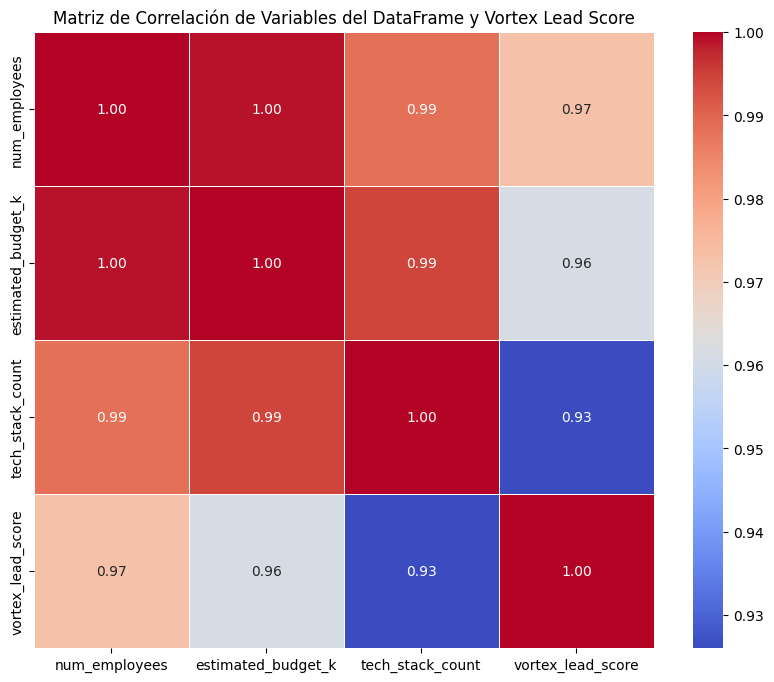

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables del DataFrame y Vortex Lead Score')
plt.show()

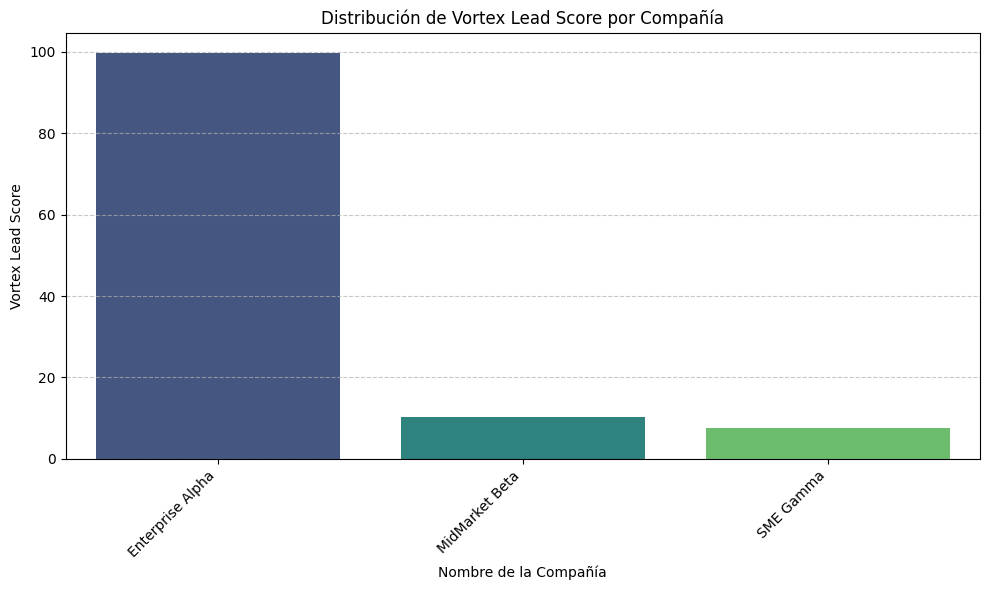

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of vortex_lead_score
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='company_name', y='vortex_lead_score', data=processed_df.sort_values(by='vortex_lead_score', ascending=False), palette='viridis', hue='company_name', legend=False)
plt.title('Distribución de Vortex Lead Score por Compañía')
plt.xlabel('Nombre de la Compañía')
plt.ylabel('Vortex Lead Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()